Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
import csv

Carga imagen ideal con monedas y convierte a RGB

(938, 473, 3)


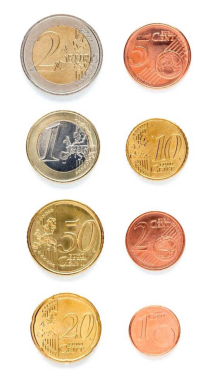

In [2]:
#Carga imagen ejemplo con monedas
img = cv2.imread('Monedas.jpg') 
print(img.shape)
#Recordar que OpenCV lee las imágenes en BGR, por lo que convertimos para visualizr a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.axis("off")
plt.imshow(img_rgb) 
plt.show()

Convierte a gris y muestra histograma

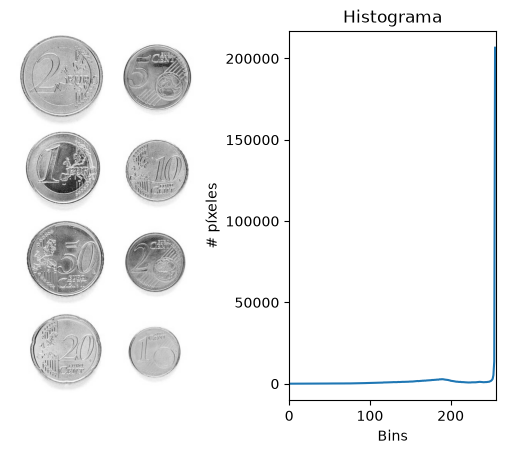

In [3]:
#Convierte la imagen a todos de gris, mostrando el resultado
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Cálculo del histograma con 256 bins de una imagen en escala de grises
hist = cv2.calcHist([img_gris], [0], None, [256], [0, 256])

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.imshow(img_gris, cmap='gray')

# Histograma sin normalizar
plt.subplot(1, 2, 2)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("# píxeles")
plt.plot(hist)
plt.xlim([0, 256])
# Separo subplots horizontalmente
plt.subplots_adjust(wspace=0.4)

Cuenta resultado tras umbralizar (poniendo a negro el fondo)

Umbral fijo usado  200.0
Umbral Otsu  204.0


Text(0.5, 1.0, 'OTSU invertida')

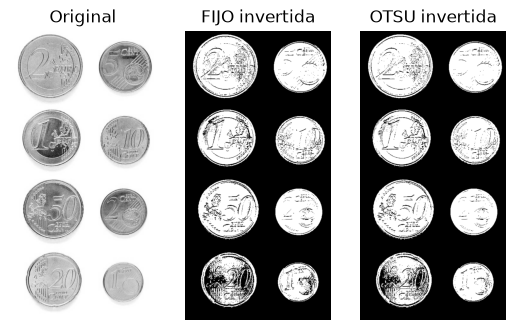

In [4]:
#Dos variantes de umbralizado. Probar otros parámetros, aplicar filtro previo, etc.
umbral = 200 # Prueba varios comenzando en 130
# Umbralizado binario invertido, dado que por defecto se asume objetos en blanco
th1,img_th1 = cv2.threshold(img_gris,umbral,255,cv2.THRESH_BINARY_INV)
print('Umbral fijo usado ', th1)
# Umbralizado con método de Otsu para selección automática del umbral
th2,img_th2 = cv2.threshold(img_gris,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
print('Umbral Otsu ', th2)

plt.subplot(1, 3, 1)
plt.axis("off")
plt.imshow(img_gris,cmap='gray') 
plt.title('Original')

plt.subplot(1, 3, 2)
plt.axis("off")
plt.imshow(img_th1,cmap='gray') 
plt.title('FIJO invertida')

plt.subplot(1, 3, 3)
plt.axis("off")
plt.imshow(img_th2,cmap='gray') 
plt.title('OTSU invertida')



Búsqueda de componentes y sus contornos

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


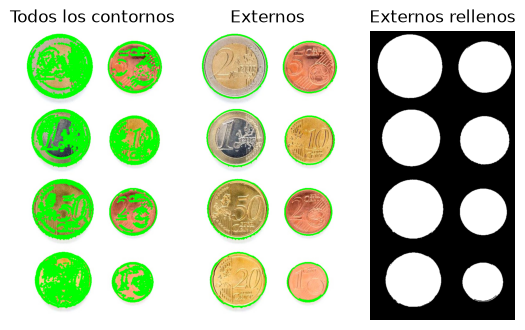

In [5]:
#Localiza contornos en imagen obtenida con umbral fijo
#findContours está diseñada para imágenes con  figura en blanco y fondo negro
#La imagen de entrada debe ser de un canal y 8 bits excepto en los modos RETR_CCOMP o RETR_FLOODFILL
#hierarchy contiene información sobre el nivel del contorno, relaciones paterno-filiales (contornos contenidos en otros)

#Obtiene todos los contornos: externos e internos
contornos, hierarchy = cv2.findContours(
    img_th1, #imagen
    cv2.RETR_TREE, #Modo de recuperación (lista, árbol, nivel superior)
    cv2.CHAIN_APPROX_SIMPLE #Método de aproximación del contorno
    )

#Dibuja sobre la imagen de entrada los contornos en verde
#Cada vez que quiere pintar convierte img para no tener restos
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.drawContours(img_rgb, contornos, -1, (0,255,0), 3)

plt.subplot(131)
plt.axis("off")
plt.imshow(img_rgb) 
plt.title('Todos los contornos')

#Obtiene únicamente los contornos externos
contornos2, hierarchy2 = cv2.findContours(img_th1, 
    cv2.RETR_EXTERNAL , 
    cv2.CHAIN_APPROX_SIMPLE)

#Dibuja sobre la imagen de entrada sólo contornos externos
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.drawContours(img_rgb, contornos2, -1, (0,255,0), 3)

plt.subplot(132)
plt.axis("off")
plt.imshow(img_rgb) 
plt.title('Externos')

#Dibuja contornos externos rellenos en imagen vacía
#Imagen negra
img_cont = np.zeros(img_rgb.shape)
#Recorre los contornos externos
for c in contornos2:
    #Área del contorno
    area = cv2.contourArea(c)
    #Área mínima (útil filtrar en ocasiones)
    if area > 10:
        #Perímetro del contorno
        perimetro = cv2.arcLength(c,True)
        #Contenedor alineado con ejes de la imagen
        x,y,w,h = cv2.boundingRect(c)
        #Mínimo contenedor ajustado para el contorno
        rect = cv2.minAreaRect(c)
        #Mínimo círculo que contiene al contorno
        (cx,cy),radio = cv2.minEnclosingCircle(c)
        #Elipse ajustada al contorno, exgigiendo un mínimo de puntos del contornos
        if c.shape[0] > 5:
            elipse = cv2.fitEllipse(c)
            #Para determinadas tareas nos puede interesará mostrar los valores obtenidos del contorno
            #print(area, perimetro, rect, cx,cy,radio, elipse)

        #Dibuja los contornos
        cv2.drawContours(img_cont, [c], -1, (255,255,255), -1)

plt.subplot(133)
plt.axis("off")
plt.imshow(img_cont) 
plt.title('Externos rellenos')
plt.show()


Alternativa contando círculos utilizando la Transformada de Hough. La selección de parámetros puede ser "divertida", más [información](https://docs.opencv.org/4.x/da/d53/tutorial_py_houghcircles.html)


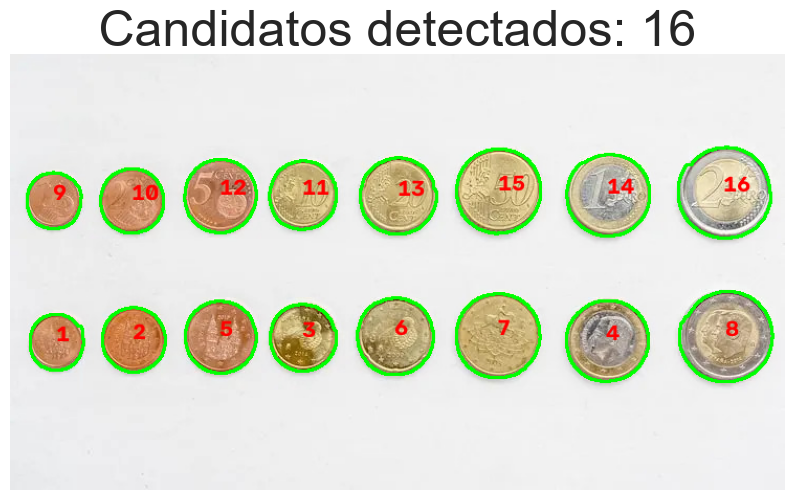

Medidas de los candidatos:
1: diámetro=52.9 px, área=2178.0, perímetro=175.2, circularidad=0.89, relación elipse=1.03
2: diámetro=61.0 px, área=2915.5, perímetro=202.4, circularidad=0.89, relación elipse=1.02
3: diámetro=63.6 px, área=3181.5, perímetro=211.2, circularidad=0.90, relación elipse=1.02
4: diámetro=78.1 px, área=4777.0, perímetro=258.5, circularidad=0.90, relación elipse=1.02
5: diámetro=68.5 px, área=3677.0, perímetro=228.3, circularidad=0.89, relación elipse=1.02
6: diámetro=73.2 px, área=4205.5, perímetro=243.4, circularidad=0.89, relación elipse=1.01
7: diámetro=80.5 px, área=5075.0, perímetro=267.3, circularidad=0.89, relación elipse=1.01
8: diámetro=87.3 px, área=5977.0, perímetro=290.2, circularidad=0.89, relación elipse=1.04
9: diámetro=53.3 px, área=2213.0, perímetro=176.9, circularidad=0.89, relación elipse=1.03
10: diámetro=61.2 px, área=2936.0, perímetro=202.2, circularidad=0.90, relación elipse=1.02
11: diámetro=65.0 px, área=3312.0, perímetro=216.7, circularid

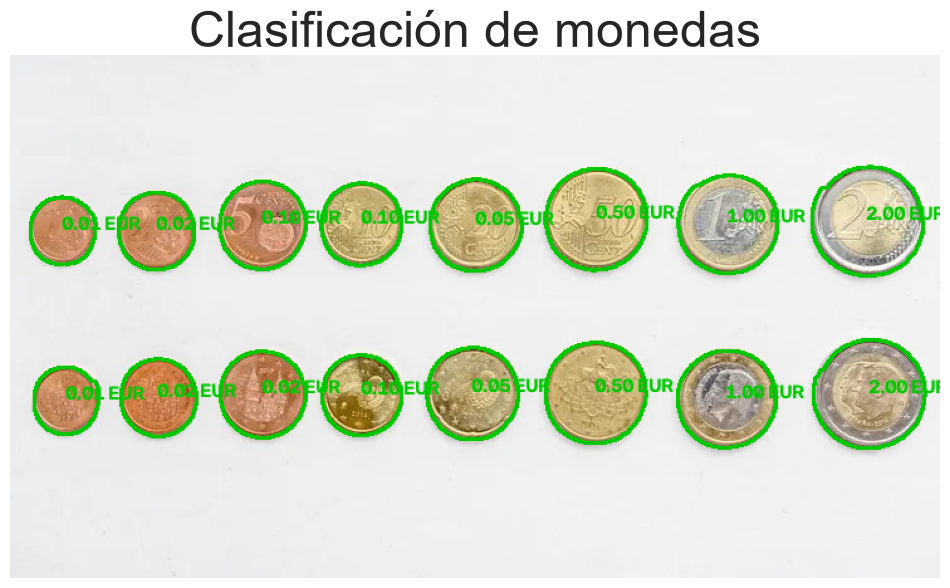


RESULTADO FINAL
Candidatos detectados: 16
Monedas clasificadas: 16
Candidatos dudosos: 0
Valor total estimado: 7.48 €


In [ ]:
# ---------------------------------------------------------
# 1. Carga y preprocesamiento de la imagen
# ---------------------------------------------------------

img = cv2.imread("money.jpg")

if img is None:
    raise FileNotFoundError("No se ha encontrado Monedas.jpg")

# Se convierte la imagen a escala de grises.
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Se suaviza la imagen para reducir el ruido.
suave = cv2.GaussianBlur(gris, (5, 5), 0)

# Se detectan los bordes de las monedas.
bordes = cv2.Canny(suave, 50, 150)

# Se cierran pequeñas interrupciones en los bordes.
kernel = np.ones((5, 5), np.uint8)
bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel, iterations=2)

# Se localizan los contornos externos.
contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# ---------------------------------------------------------
# 2. Filtrado de contornos mediante propiedades geométricas
# ---------------------------------------------------------

candidatos = []
alto_img, ancho_img = gris.shape
area_img = alto_img * ancho_img

for c in contornos:

    # Área y perímetro del contorno.
    area = cv2.contourArea(c)
    perimetro = cv2.arcLength(c, True)

    if perimetro == 0:
        continue

    # Se descartan objetos demasiado pequeños o demasiado grandes.
    if area < area_img * 0.0002 or area > area_img * 0.20:
        continue

    # Compacidad: permite comprobar cuánto se aproxima el contorno
    # a una forma compacta. Para un círculo ideal, P²/A = 4*pi.
    compacidad = (perimetro ** 2) / area

    # Se utiliza la circularidad para filtrar formas irregulares.
    circularidad = (4 * np.pi * area) / (perimetro ** 2)

    if circularidad < 0.65:
        continue

    # Rectángulo alineado con los ejes de la imagen.
    x, y, w, h = cv2.boundingRect(c)

    # Se descartan contornos excesivamente alargados.
    relacion = min(w, h) / max(w, h)

    if relacion < 0.75:
        continue

    # Se ajusta una elipse si hay suficientes puntos.
    if len(c) >= 5:
        elipse = cv2.fitEllipse(c)
        (centro, ejes, orientacion) = elipse

        eje_mayor = max(ejes)
        eje_menor = min(ejes)

        # Relación entre los ejes de la elipse.
        relacion_elipse = eje_mayor / eje_menor

        if relacion_elipse > 1.35:
            continue

        # Se estima el diámetro mediante la media de los ejes.
        # Así se reduce la influencia de pequeñas irregularidades.
        diametro_px = (eje_mayor + eje_menor) / 2

        cx = int(centro[0])
        cy = int(centro[1])

    else:
        continue

    # Se guardan las medidas de los candidatos válidos.
    candidatos.append({
        "contorno": c,
        "x": cx,
        "y": cy,
        "diametro_px": diametro_px,
        "area": area,
        "perimetro": perimetro,
        "compacidad": compacidad,
        "circularidad": circularidad,
        "relacion": relacion,
        "relacion_elipse": relacion_elipse
    })

# ---------------------------------------------------------
# 3. Visualización de los candidatos detectados
# ---------------------------------------------------------

vista = img.copy()
font = cv2.FONT_HERSHEY_SIMPLEX

for i, c in enumerate(candidatos):

    # Se dibuja el contorno del candidato.
    cv2.drawContours(vista, [c["contorno"]], -1, (0, 255, 0), 2)

    # Se numera cada candidato para poder seleccionarlo como referencia.
    cv2.putText(vista, str(i + 1), (c["x"], c["y"]), font, 0.7, (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vista, cv2.COLOR_BGR2RGB))
plt.title(f"Candidatos detectados: {len(candidatos)}")
plt.axis("off")
plt.show()

print("Medidas de los candidatos:")

for i, c in enumerate(candidatos):
    print(
        f"{i + 1}: diámetro={c['diametro_px']:.1f} px, "
        f"área={c['area']:.1f}, "
        f"perímetro={c['perimetro']:.1f}, "
        f"circularidad={c['circularidad']:.2f}, "
        f"relación elipse={c['relacion_elipse']:.2f}"
    )

# ---------------------------------------------------------
# 4. Calibración con una moneda de valor conocido
# ---------------------------------------------------------

indice_ref = int(input(
    "\nNúmero de la moneda de referencia: "
)) - 1

if indice_ref < 0 or indice_ref >= len(candidatos):
    raise ValueError("El número seleccionado no es válido.")

valor_ref = float(input(
    "Valor de la moneda de referencia (ej. 0.50, 1 o 2): "
))

# Diámetros oficiales aproximados de las monedas de euro (mm).
diametros_euro = {
    0.01: 16.25,
    0.02: 18.75,
    0.05: 21.25,
    0.10: 19.75,
    0.20: 22.25,
    0.50: 24.25,
    1.00: 23.25,
    2.00: 25.75
}

if valor_ref not in diametros_euro:
    raise ValueError("La denominación introducida no es válida.")

# Se calcula la escala en milímetros por píxel.
diametro_ref = candidatos[indice_ref]["diametro_px"]
mm_por_pixel = diametros_euro[valor_ref] / diametro_ref

print(f"\nEscala: {mm_por_pixel:.4f} mm/píxel")


# 5. Clasificación por diámetro y color

# Se convierte la imagen a HSV para analizar el tono de las monedas.
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

tolerancia_mm = 1.5

# Umbral aproximado para distinguir el tono cobrizo del dorado.
# En OpenCV, el tono HSV toma valores entre 0 y 179.
umbral_tono = 15

vista_final = img.copy()
total = 0.0
clasificadas = 0
sin_clasificar = 0

for c in candidatos:
    diametro_mm = c["diametro_px"] * mm_por_pixel

    # Se calcula el error respecto al diámetro de cada moneda.
    errores = {}
    for valor in diametros_euro:
        errores[valor] = abs(diametros_euro[valor] - diametro_mm)

    # Se selecciona inicialmente la moneda cuyo diámetro
    # real es el más parecido al diámetro estimado.
    valor_probable = min(errores, key=errores.get)
    error_minimo = errores[valor_probable]

    # Se comprueba si el diámetro permite confundir
    # una moneda de 2 céntimos con una de 10 céntimos.
    if errores[0.02] <= tolerancia_mm and errores[0.10] <= tolerancia_mm:

        # Se crea una máscara que contiene únicamente
        # el interior del contorno de la moneda.
        mascaraColor = np.zeros(gris.shape, dtype=np.uint8)
        cv2.drawContours(mascaraColor, [c["contorno"]], -1, 255, -1)

        # Se erosionan los bordes de la máscara para reducir
        # la influencia del fondo y del contorno exterior.
        kernelColor = np.ones((5, 5), np.uint8)
        mascaraColor = cv2.erode(mascaraColor, kernelColor, iterations=2)

        # Se obtienen los píxeles HSV que pertenecen a la moneda.
        pixeles = hsv[mascaraColor == 255]

        if len(pixeles) > 0:
            tonos = pixeles[:, 0]
            saturaciones = pixeles[:, 1]
            brillos = pixeles[:, 2]

            # Se descartan píxeles poco saturados, muy oscuros
            # o excesivamente brillantes, porque pueden distorsionar
            # la estimación del color por las sombras y los reflejos.
            validos = ((saturaciones > 40) & (brillos > 30) & (brillos < 245))

            tonosValidos = tonos[validos]

            if len(tonosValidos) > 0:
                # La mediana reduce la influencia de píxeles atípicos.
                tonoMediano = np.median(tonosValidos)

                # Se usa el tono para distinguir el cobre del dorado.
                if tonoMediano <= umbral_tono:
                    valor_probable = 0.02
                else:
                    valor_probable = 0.10

                error_minimo = errores[valor_probable]

    # Se acepta la clasificación si el diámetro es compatible
    # con el valor seleccionado.
    if error_minimo <= tolerancia_mm:
        total += valor_probable
        clasificadas += 1
        color = (0, 200, 0)
        etiqueta = f"{valor_probable:.2f} EUR"
    else:
        sin_clasificar += 1
        color = (0, 165, 255)
        etiqueta = "Dudosa"

    # Se dibuja el contorno y la denominación estimada.
    cv2.drawContours(vista_final, [c["contorno"]], -1, color, 2)
    cv2.putText(vista_final, etiqueta, (c["x"], c["y"]), font, 0.5, color, 2)

# ---------------------------------------------------------
# 6. Resultado final
# ---------------------------------------------------------

plt.figure(figsize=(12, 9))
plt.imshow(cv2.cvtColor(vista_final, cv2.COLOR_BGR2RGB))
plt.title("Clasificación de monedas")
plt.axis("off")
plt.show()

print("\nRESULTADO FINAL")
print(f"Candidatos detectados: {len(candidatos)}")
print(f"Monedas clasificadas: {clasificadas}")
print(f"Candidatos dudosos: {sin_clasificar}")
print(f"Valor total estimado: {total:.2f} €")


Las formas localizadas tienen distintas características geométricas, que pueden estimarse a partir de sus contornos. Más información en la [documentación de OpenCV](https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html).

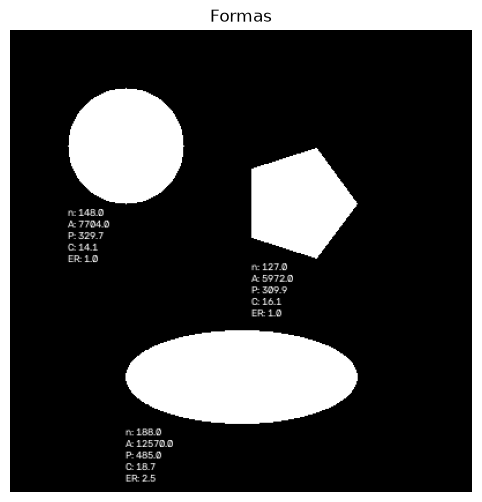

In [7]:
#Creación de polígono regular
def poligono_regular(image, ctr, radio, lados, color):
    pts = []
    ang_step = 2 * np.pi / lados
    for i in range(lados):
        ang = i * ang_step
        x = int(ctr[0] + radio * np.cos(ang))
        y = int(ctr[1] + radio * np.sin(ang))
        pts.append((x, y))
    pts = np.array(pts, np.int32)
    #regorganiza
    pts = pts.reshape((-1, 1, 2))
    cv2.fillPoly(image, [pts], color=color)

# Imagen vacía
img = np.zeros((400, 400, 1), dtype="uint8")
color = (255, 255, 255)

# Formas básicas
cv2.circle(img, (100, 100), 50, color, -1)  # Circular
poligono_regular(img, (250, 150), 50, 5, color)  # Polígono regular
cv2.ellipse(img, (200, 300), (100, 40), 0, 0, 360, color, -1)  # Elíptica

# Localiza contornos
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Parámeros texto
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
thickness = 1

# Process each contour to calculate compactness and ellipse ratio (if possible)
for c in contours:
    # Puntos del contorno
    clon = len(c)

    # Área y perímetro
    area = cv2.contourArea(c)
    perimetro = cv2.arcLength(c, True)

    #Contenedor alineado con ejes de la imagen
    x,y,w,h = cv2.boundingRect(c)
    
    # Compactness: 4*pi*Area/Perimeter^2
    if perimetro > 0:
        compacidad = (perimetro ** 2) / area
    else:
        compactness = 0
    
    # Ajusta elipse si hay suficientes puntos
    if clon >= 5:
        elipse = cv2.fitEllipse(c)
        (center, axes, orientation) = elipse
        major_axis = max(axes)
        minor_axis = min(axes)
        elipse_ratio = major_axis / minor_axis
    else:
        elipse_ratio = None
    
    # Muestra valores en imageb
    cv2.putText(img, f"n: {clon:.1f}", (x, int(y+h+10)), font, font_scale, (255, 255, 255), thickness)
    cv2.putText(img, f"A: {area:.1f}", (x, int(y+h+20)), font, font_scale, (255, 255, 255), thickness)
    cv2.putText(img, f"P: {perimetro:.1f}", (x, int(y+h+30)), font, font_scale, color, thickness)
    cv2.putText(img, f"C: {compacidad:.1f}", (x, int(y+h+40)), font, font_scale, color, thickness)
    cv2.putText(img, f"ER: {elipse_ratio:.1f}", (x, int(y+h+50)), font, font_scale, color, thickness)
    
# Visualiza la imagen
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Formas")
plt.axis('off')
plt.show()


TAREA: Los ejemplos ilustrativos anteriores permiten saber el número de monedas presentes en la imagen ideal proporcionada. ¿Cómo determinar la cantidad de dinero presente en ella? A partir únicamente de las dimensiones, una sugerencia impicaríaj en primer término identificar de forma interactiva (por ejemplo haciendo clic en la imagen) una moneda de un valor fijo en la imagen (por ejemplo de 1€) para permitir establecer una relación entre píxeles y mo¡ilímetros. Tras obtener esa información y las dimensiones en milímetros de las distintas monedas, es factible calcular la cantidad de dinero en la imagen ideal.

Una vez resuelto el reto con la imagen ideal proporcionada, diseña un demostrador en vivo que a partir de la entrada de vídeo de la cámara, determine el dinero presente en la escena. Si bien 
no hay restricciones sobre utilizar medidas geométricas o de color, o cualquier clasificador, no deben hacer uso de modelos de aprendizaje profundo. ¿Funciona correctamente? ¿Se observan problemas?
Posibles extras serían la presencia de objetos que no son monedas y/o haya solape entre las monedas.

IMPORTANTE: No se admite el uso de modelos de aprendizaje profundo

Nota: Para establecer la correspondencia entre píxeles y milímetros, comentar que la moneda de un euro tiene un diámetro de 23.25 mm. la de 50 céntimos de 24.35, la de 20 céntimos de 22.25, etc. 



La segunda tarea plantea la clasificación de microplásticos en una imagen real. Dado que el mundo real es muy variado, las imágenes no siempre se capturan con unas condiciones de iluminación tan buenas o controladas. Ejemplo con aplicación de variantes de umbralizados ofrecidas por OpenCV sobre una imagen de muestras de microplásticos.

Umbral escogido  197.0


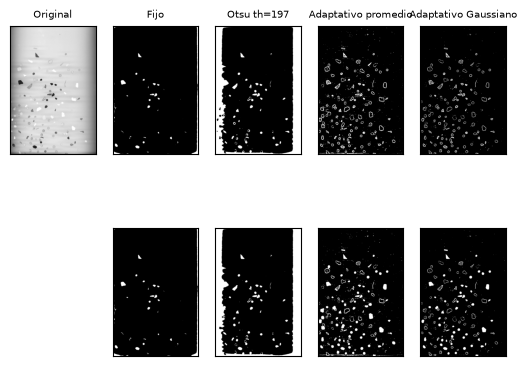

In [8]:
#Carga imagen directamente en grises
imgorig = cv2.imread('MPs_test.jpg', cv2.IMREAD_GRAYSCALE) 

img = cv2.GaussianBlur(imgorig,(5,5),0)

#Umbralizados
ret,imth1 = cv2.threshold(img,150,255,cv2.THRESH_BINARY_INV)
thotsu,imth2 = cv2.threshold(img,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
print('Umbral escogido ', thotsu)
imth3 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C,\
            cv2.THRESH_BINARY,11,2)
imth4 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,11,2)
 
titles = ['Original', 'Fijo','Otsu th='+str(int(thotsu)),
            'Adaptativo promedio', 'Adaptativo Gaussiano']
images = [img, imth1, imth2, 255 - imth3, 255 - imth4]
 
for i in range(5):
    plt.subplot(2,5,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i], fontsize=7)
    plt.xticks([]),plt.yticks([])

    #Obtiene únicamente los contornos externos
    if i>0:
        res,imth = cv2.threshold(images[i],120,255,cv2.THRESH_BINARY)
        contornos, hierarchy= cv2.findContours(imth, 
        cv2.RETR_EXTERNAL , 
        cv2.CHAIN_APPROX_SIMPLE)  
        img_cont = np.zeros(img.shape)
        cv2.drawContours(img_cont, contornos, -1, (255,255,255), -1)  
        plt.subplot(2,5,i+6),plt.imshow(img_cont,'gray')
        plt.xticks([]),plt.yticks([])
plt.show()

Para esta imagen de muestras de microplásticos tenemos una anotación (que puede contener errores) de la tipología de las partículas. Esta será la imagen de test en los experimentos posteriores, no puedes hacer uso de esta imagen para entrenar tu clasificador, solo par evaluarlo

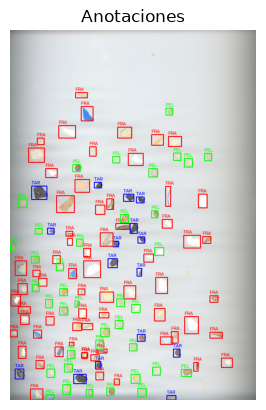

In [9]:
# Imagen y anotaciones
imagen = "MPs_test.jpg"          # Imagen original
csv_file = "MPs_test_bbs.csv"  # CSV con coordenadas y tipología

# Colores de cada clase
colores = {
    "FRA": (0, 0, 255),   # Rojo 
    "PEL": (0, 255, 0),   # Verde
    "TAR": (255, 0, 0)    # Azul
}

# Imagen
img = cv2.imread(imagen)

# Cara csv y dibujar rectángulos
with open(csv_file, newline="") as file:
    reader = csv.DictReader(file)
    for row in reader:
        etiqueta = row["label"]
        x_min, y_min, x_max, y_max = map(int, [row["x_min"], row["y_min"], row["x_max"], row["y_max"]])
        
        # Color según etiqueta
        color = colores.get(etiqueta, (0, 0, 0))  # negro por defecto si no encuentra
        
        # Dibujar rectángulo
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 2)
        
        # Etiqueta 
        cv2.putText(img, etiqueta, (x_min, y_min - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Visualiza resultado
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Anotaciones")
plt.axis('off')
plt.show()


##Muestras de entrenamiento

Text(0.5, 1.0, 'Alquitrán')

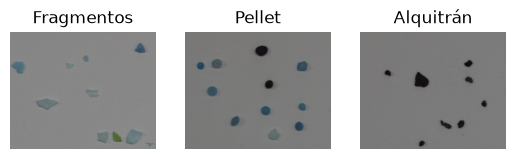

In [10]:
#Cargamos tres subimágenes, por simplicidad, de cada uno de los tres tipos considerados (reiterar que el alquitrán no es microplástico)
imgF = cv2.imread('FRA.png') 
imgP = cv2.imread('PEL.png') 
imgT = cv2.imread('TAR.png') 

#Mostramos
plt.subplot(131)
plt.axis("off")
plt.imshow(imgF) 
plt.title('Fragmentos')
plt.subplot(132)
plt.axis("off")
plt.imshow(imgP) 
plt.title('Pellet')
plt.subplot(133)
plt.axis("off")
plt.imshow(imgT) 
plt.title('Alquitrán')

El objetivo de la siguiente tarea, descrita más abajo, es desarrollar tu propio clasificador basado únicamente en heurísticas basadas en características geométricas y/o de apariencia, a partir de las imágenes completas de las partículas de cada tipo, debiendo mostrar la bondad del clasificador haciendo uso de métricas para ello sobre las anotaciones de la imagen de test *MPs_test.png*. La siguiente celda obtiene varias métricas para un conjunto de datos imaginario (y con etiquetas aleatorias). Si bien las trataremos con más detalle en teoría, muestro un repertorio de ellas, dando más peso a la matriz de confusión. La ejecución de la celda requiere instalar el paquete scikit-learn.

¿Qué es una matriz de confusión?
Se utiliza para mostrar el comportamiento de un clasificador para las distintas clases conocidas, se relacionan las etiquetas de las muestras anotadas frente a las predichas por el clasificador. Se busca una matriz diagonal, pero la perfección es infrecuente.

El siguiente ejemplo, muestra el modo de obtener la matriz de confusión para un hipotético problema con cuatro clases, y valores de anotación (variable y) y predicción (variable y_pred) obtenidos de forma aleatoria.

Anotaciones  [3, 2, 2, 3, 3, 2, 1, 2, 2, 2, 1, 1, 2, 3, 2, 2, 3, 1, 0, 2, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1, 2, 3, 3, 0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 0, 0, 3, 3, 3, 1, 0, 2, 2, 1, 3, 2, 0, 2, 0, 3, 0, 1, 3, 2, 1, 1, 2, 1, 1, 1, 3, 1, 2, 1, 0, 3, 2, 2, 3, 2, 3, 1, 0, 2, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 0, 0, 1]
Predicciones  [1, 3, 0, 2, 2, 2, 3, 0, 3, 2, 0, 1, 2, 3, 2, 2, 0, 0, 0, 3, 1, 2, 1, 0, 0, 0, 3, 3, 0, 0, 2, 1, 0, 0, 1, 2, 0, 0, 2, 0, 0, 0, 3, 2, 1, 1, 2, 2, 2, 3, 1, 1, 0, 3, 1, 1, 0, 1, 2, 0, 0, 0, 1, 3, 2, 1, 2, 1, 1, 3, 3, 0, 2, 1, 1, 1, 1, 3, 3, 1, 0, 1, 3, 3, 1, 2, 3, 2, 1, 1, 1, 3, 0, 3, 1, 0, 0, 2, 2, 3]
¿Cómo de bien encajan anotación y predicción?
Accuracy (TP/(n))= 0.31
Precision (TP/(TP+FP)) = 0.3202173913043479
Recall (TP/(TP+FN)) = 0.31
F1 Score (2*(precision*recall)/(precision+recall)) = 0.3108503496503497


Text(38.236490885416664, 0.5, 'Real/Anotado')

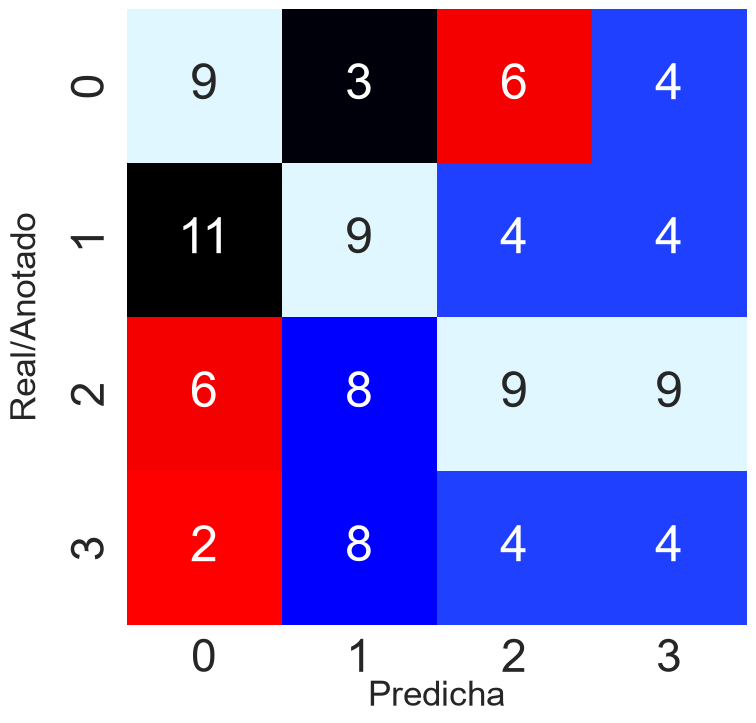

In [11]:

import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Numero de muestras
n = 100  
nclases = 4

# A falta de clasificador y conjunto de datos, creamos anotaciones y predicciones de forma aleatoria
# Vector aleatorio con etiquetas anotadas
y = [random.randint(0, nclases - 1) for _ in range(n)]
print('Anotaciones ' , y)

# Vector aleatorio con etiquetas predichas por un supuesto clasificador
y_pred = [random.randint(0, nclases - 1) for _ in range(n)]
print('Predicciones ' , y_pred)

print('¿Cómo de bien encajan anotación y predicción?')

#Cálculo de métricas
accuracy = accuracy_score(y, y_pred)
#Para más de una clase se define la forma de promediar
precision = precision_score(y, y_pred,average='weighted')
recall = recall_score(y, y_pred,average='weighted')
f1score = f1_score(y, y_pred,average='weighted')

print(f"Accuracy (TP/(n))= {accuracy}")
print(f"Precision (TP/(TP+FP)) = {precision}")
print(f"Recall (TP/(TP+FN)) = {recall}")
print(f"F1 Score (2*(precision*recall)/(precision+recall)) = {f1score}")


conf_matrix = confusion_matrix(y, y_pred)
plt.figure(figsize=(8,8))
sns.set(font_scale = 1.75)#tamaños tipografía
sns.set(font_scale = 3.0)

ax = sns.heatmap(
        conf_matrix, # confusion matrix 2D array 
        annot=True, # Muestra números en las celdas
        fmt='d', # valores enteros
        cbar=False, # sin barra de colores
        cmap='flag', # mapa de colores
        #vmax=175 # contraste de color
    )

#Etiquetas matriz de confusión
label_font = {'size':'25'}
ax.set_xlabel("Predicha", labelpad=-0.75, fontdict=label_font)
ax.set_ylabel("Real/Anotado", labelpad=20, fontdict=label_font)

TAREA: La tarea consiste en extraer características (geométricas y/o visuales) de las tres imágenes completas de partida, y *aprender* patrones que permitan identificar las partículas en nuevas imágenes. Para ello se proporciona como imagen de test *MPs_test.jpg* y sus correpondientes anotaciones *MPs_test_bbs.csv* con la que deben obtener las métricas para su propuesta de clasificación de microplásticos, además de la matriz de confusión. La matriz de confusión permitirá mostrar para cada clase el número de muestras que se clasifican correctamente de dicha clase, y el número de muestras que se clasifican incorrectamente como perteneciente a una de las otras dos clases. De nuevo, no deben hacer uso de modelos de aprendizaje profundo ni para segmentar, ni para clasificar.

En el trabajo [SMACC: A System for Microplastics Automatic Counting and Classification](https://doi.org/10.1109/ACCESS.2020.2970498), las características geométricas utilizadas fueron:

- Área en píxeles
- Perímetro en píxeles
- Compacidad (relación entre el cuadrado del perímetro y el área de la partícula)
- Relación del área de la partícula con la del contenedor
- Relación del ancho y el alto del contenedor
- Relación entre los ejes de la elipse ajustada
- Definido el centroide, relación entre las distancias menor y mayor al contorno

Si no se quedan satisfechos con la segmentación obtenida, es el mundo real, también en el README comento técnicas recientes de segmentación, que podrían despertar su curiosidad.

IMPORTANTE: No se admite el uso de modelos de aprendizaje profundo